In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')

print(f"Loaded: {len(df):,} transactions")
print(f"Fraud cases: {df['Class'].sum():,}")
print(f"Fraud rate: {(df['Class'].sum() / len(df)) * 100:.3f}%")
print(f"Features: {df.shape[1]}")
print(f"\nMissing values: {df.isnull().sum().sum()}")

df.head()

Loaded: 284,807 transactions
Fraud cases: 492
Fraud rate: 0.173%
Features: 31

Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


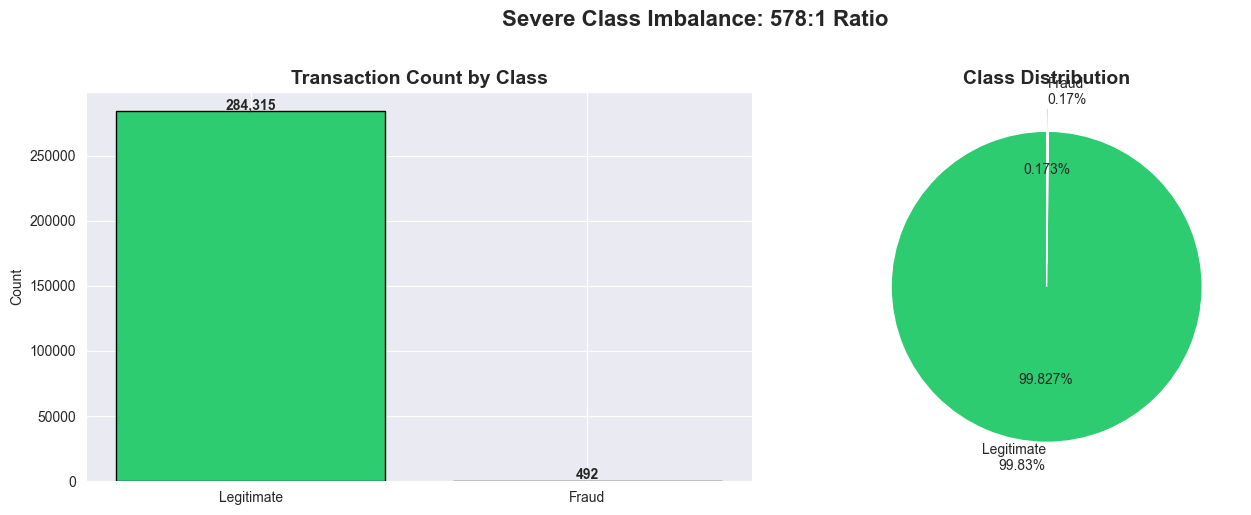

Imbalance ratio: 577:1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
axes[0].bar(['Legitimate', 'Fraud'],
            df['Class'].value_counts().values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Transaction Count by Class', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['Class'].value_counts().values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Percentage pie chart
axes[1].pie([284315, 492],
            labels=['Legitimate\n99.83%', 'Fraud\n0.17%'],
            colors=['#2ecc71', '#e74c3c'],
            explode=(0, 0.15),
            autopct='%1.3f%%',
            startangle=90)
axes[1].set_title('Class Distribution', fontsize=14, fontweight='bold')

plt.suptitle('Severe Class Imbalance: 578:1 Ratio', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../models/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Imbalance ratio: {284315//492}:1")

C:\Users\Saadi\AppData\Local\Temp\ipykernel_17468\4207780226.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_to_plot, labels=['Legitimate', 'Fraud'],


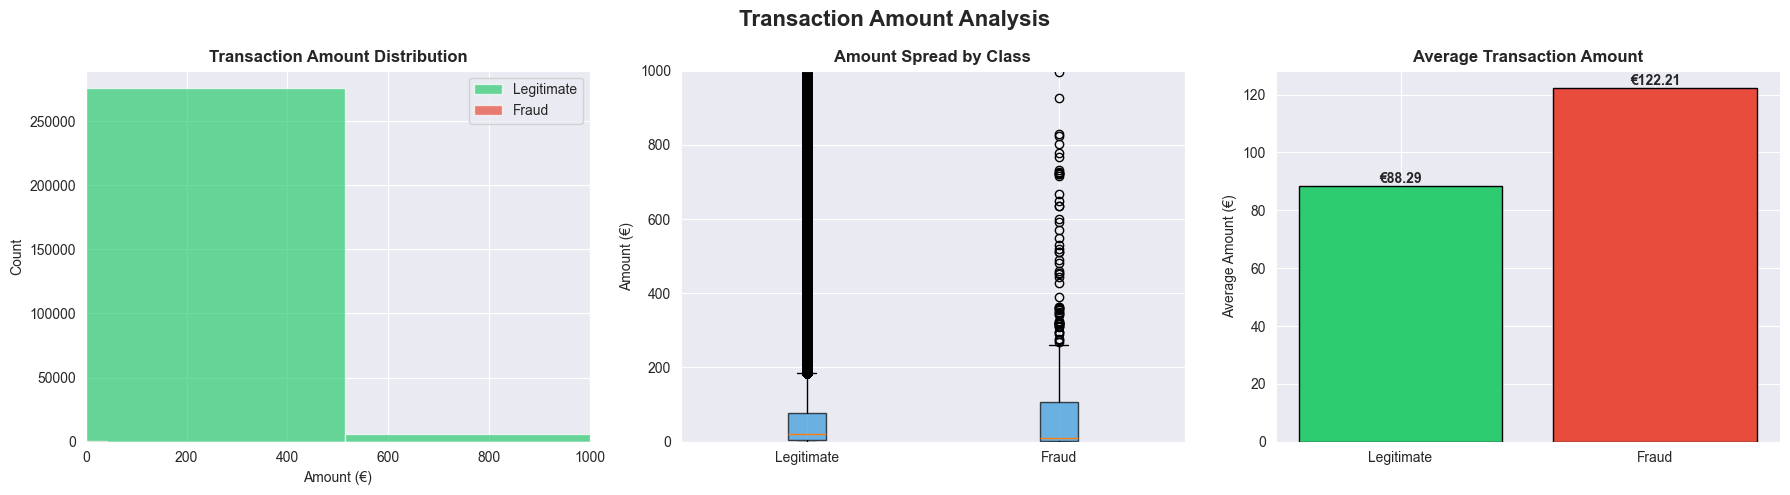

Avg Legitimate: €88.29
Avg Fraud:      €122.21
Max Legitimate: €25691.16
Max Fraud:      €2125.87


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fraud vs Legitimate amount distribution
axes[0].hist(df[df['Class']==0]['Amount'], bins=50,
             color='#2ecc71', alpha=0.7, label='Legitimate')
axes[0].hist(df[df['Class']==1]['Amount'], bins=50,
             color='#e74c3c', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_xlim(0, 1000)

# Box plot
data_to_plot = [df[df['Class']==0]['Amount'].values,
                df[df['Class']==1]['Amount'].values]
axes[1].boxplot(data_to_plot, labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_title('Amount Spread by Class', fontweight='bold')
axes[1].set_ylabel('Amount (€)')
axes[1].set_ylim(0, 1000)

# Average amounts
avgs = [df[df['Class']==0]['Amount'].mean(),
        df[df['Class']==1]['Amount'].mean()]
axes[2].bar(['Legitimate', 'Fraud'], avgs,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[2].set_title('Average Transaction Amount', fontweight='bold')
axes[2].set_ylabel('Average Amount (€)')
for i, v in enumerate(avgs):
    axes[2].text(i, v + 1, f'€{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Transaction Amount Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg Legitimate: €{df[df['Class']==0]['Amount'].mean():.2f}")
print(f"Avg Fraud:      €{df[df['Class']==1]['Amount'].mean():.2f}")
print(f"Max Legitimate: €{df[df['Class']==0]['Amount'].max():.2f}")
print(f"Max Fraud:      €{df[df['Class']==1]['Amount'].max():.2f}")

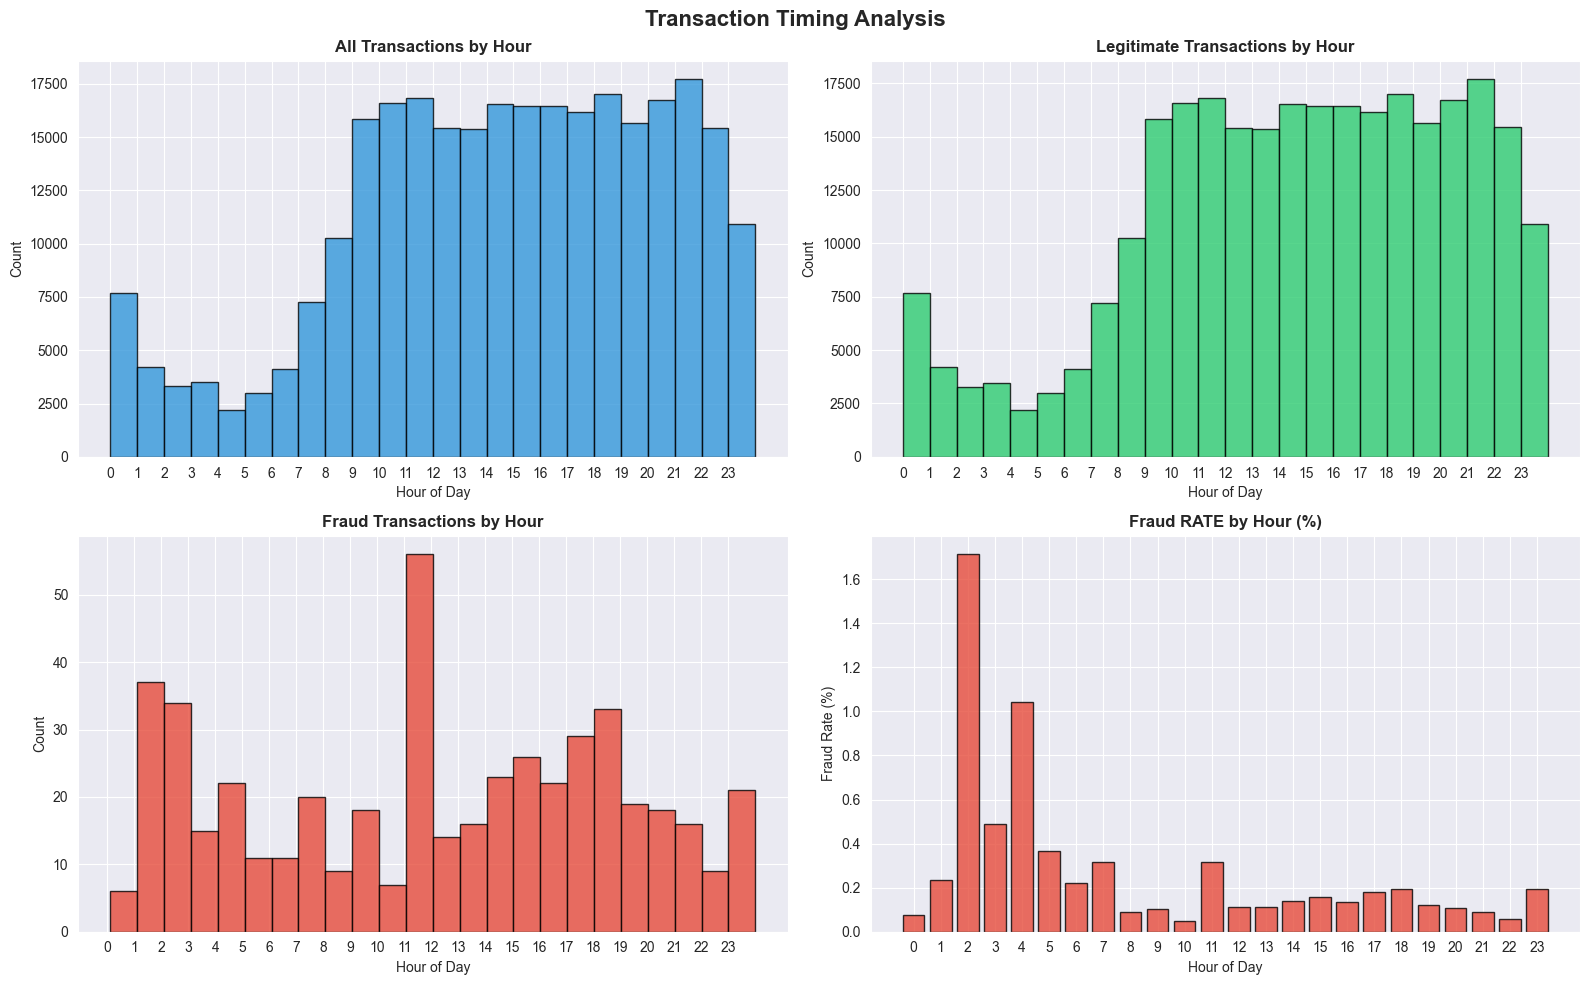

Top 3 highest fraud rate hours: [2, 4, 3]
Peak fraud rate: 1.71%


In [8]:
# Create hour feature
df['Hour'] = (df['Time'] / 3600) % 24

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# All transactions by hour
axes[0,0].hist(df['Hour'], bins=24, color='#3498db', edgecolor='black', alpha=0.8)
axes[0,0].set_title('All Transactions by Hour', fontweight='bold')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticks(range(0, 24))

# Legitimate by hour
axes[0,1].hist(df[df['Class']==0]['Hour'], bins=24,
               color='#2ecc71', edgecolor='black', alpha=0.8)
axes[0,1].set_title('Legitimate Transactions by Hour', fontweight='bold')
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Count')
axes[0,1].set_xticks(range(0, 24))

# Fraud by hour
fraud_hours = df[df['Class']==1]['Hour']
axes[1,0].hist(fraud_hours, bins=24,
               color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1,0].set_title('Fraud Transactions by Hour', fontweight='bold')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xticks(range(0, 24))

# Fraud rate by hour
fraud_rate_by_hour = df.groupby(df['Hour'].astype(int))['Class'].mean() * 100
axes[1,1].bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values,
              color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1,1].set_title('Fraud RATE by Hour (%)', fontweight='bold')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Fraud Rate (%)')
axes[1,1].set_xticks(range(0, 24))

plt.suptitle('Transaction Timing Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

peak_fraud_hours = fraud_rate_by_hour.nlargest(3)
print(f"Top 3 highest fraud rate hours: {peak_fraud_hours.index.tolist()}")
print(f"Peak fraud rate: {peak_fraud_hours.values[0]:.2f}%")

In [11]:
import numpy as np

def engineer_features(df):
    df = df.copy()

    # Time features
    df['Hour'] = (df['Time'] / 3600) % 24
    df['Is_Night'] = ((df['Hour'] >= 22) | (df['Hour'] <= 6)).astype(int)

    # Amount features
    df['Amount_log'] = np.log1p(df['Amount'])
    df['Amount_Squared'] = df['Amount'] ** 2
    df['Is_Round_Amount'] = (df['Amount'] % 1 == 0).astype(int)

    # Drop original Time and Amount (replaced by better versions)
    df = df.drop(['Time', 'Amount'], axis=1)

    return df

df_engineered = engineer_features(df)

print(f"Original features: {df.shape[1]}")
print(f"Engineered features: {df_engineered.shape[1]}")
print(f"\nNew features added:")
print("Hour - what hour transaction happened")
print("Is_Night - 1 if between 10pm-6am (high fraud period)")
print("Amount_log - removes skew from amount distribution")
print("Amount_Squared - captures extreme amounts")
print("Is_Round_Amount - fraudsters often use round numbers")

df_engineered.head()

Original features: 32
Engineered features: 34

New features added:
Hour - what hour transaction happened
Is_Night - 1 if between 10pm-6am (high fraud period)
Amount_log - removes skew from amount distribution
Amount_Squared - captures extreme amounts
Is_Round_Amount - fraudsters often use round numbers


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V25,V26,V27,V28,Class,Hour,Is_Night,Amount_log,Amount_Squared,Is_Round_Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.128539,-0.189115,0.133558,-0.021053,0,0.000000,1,5.014760,22386.1444,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,0.167170,0.125895,-0.008983,0.014724,0,0.000000,1,1.305626,7.2361,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,-0.327642,-0.139097,-0.055353,-0.059752,0,0.000278,1,5.939276,143383.3956,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.647376,-0.221929,0.062723,0.061458,0,0.000278,1,4.824306,15252.2500,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.206010,0.502292,0.219422,0.215153,0,0.000556,1,4.262539,4898.6001,0


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import joblib

# Split data
X = df_engineered.drop('Class', axis=1)
y = df_engineered['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {len(X_train):,} transactions")
print(f"Test set: {len(X_test):,} transactions")
print(f"Fraud in test: {y_test.sum()} cases")

# Train XGBoost with class imbalance handling
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(f"\nscale_pos_weight: {scale:.1f} (handles 578:1 imbalance)")

model = XGBClassifier(
    scale_pos_weight=scale,
    max_depth=6,
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc'
)

print("\nTraining model...")
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

# Evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)

print("\n" + "="*50)
print("MODEL RESULTS")
print("="*50)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Legitimate', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix:")
print(f"True Negatives (Legit correctly identified):  {cm[0][0]:,}")
print(f"False Positives (Legit flagged as fraud):     {cm[0][1]:,}")
print(f"False Negatives (Fraud missed):               {cm[1][0]:,}")
print(f"True Positives (Fraud correctly caught):      {cm[1][1]:,}")

fraud_caught = cm[1][1] / (cm[1][0] + cm[1][1]) * 100
print(f"\nFraud Caught: {fraud_caught:.1f}%")

# Save model
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/fraud_detector.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_names.pkl')
print(f"\n Model saved to models/fraud_detector.pkl")

Training set: 227,845 transactions
Test set: 56,962 transactions
Fraud in test: 98 cases

scale_pos_weight: 577.3 (handles 578:1 imbalance)

Training model...

MODEL RESULTS
ROC-AUC Score: 0.9821

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
True Negatives (Legit correctly identified):  56,849
False Positives (Legit flagged as fraud):     15
False Negatives (Fraud missed):               16
True Positives (Fraud correctly caught):      82

Fraud Caught: 83.7%

 Model saved to models/fraud_detector.pkl


Calculating SHAP values (takes ~1 min)...


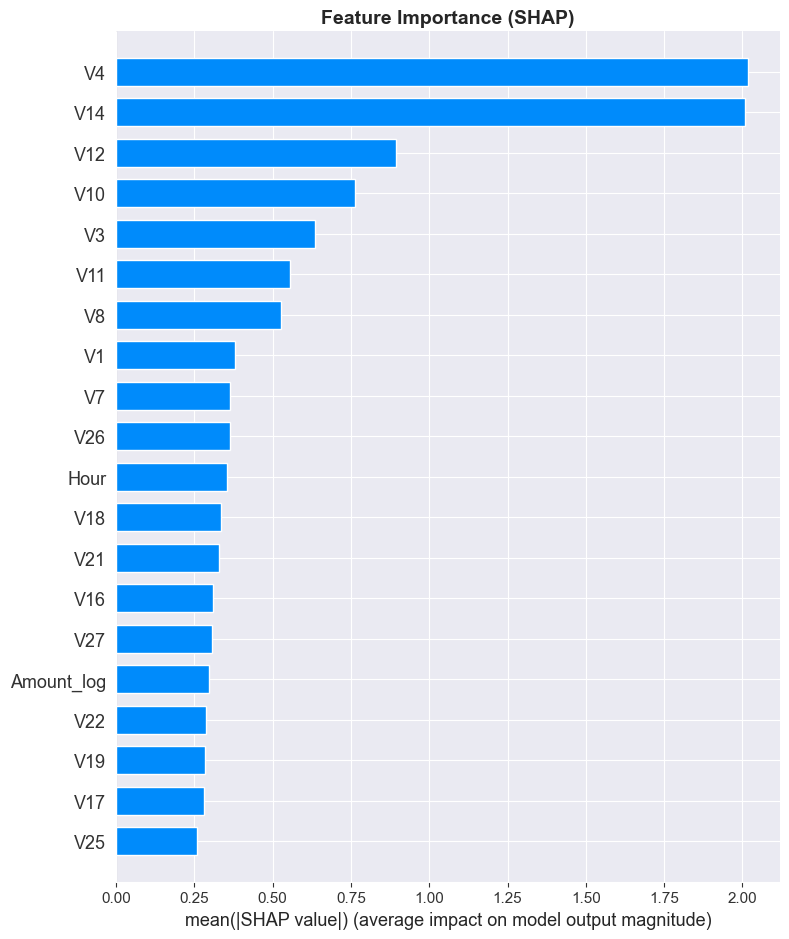

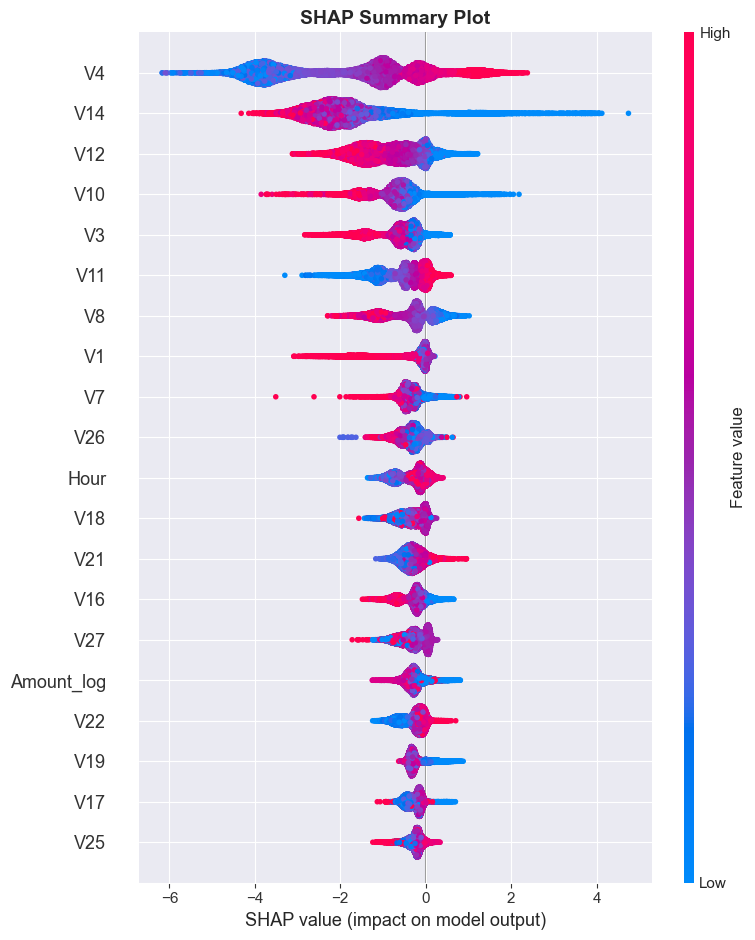


Top 5 most important features for fraud detection:
   Feature  SHAP_Importance
3       V4         2.018915
13     V14         2.008270
11     V12         0.894248
9      V10         0.762810
2       V3         0.634267


In [14]:
import shap

print("Calculating SHAP values (takes ~1 min)...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot 1: Feature Importance (Bar)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test,
                  plot_type="bar",
                  show=False)
plt.title('Feature Importance (SHAP)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../models/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: SHAP Summary (Beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features for fraud detection:")
feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

print(feature_importance.head())